In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from uncertainties import unumpy as unp
from uncertainties import ufloat
from uncertainties.unumpy import log as ulog
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
from functions import *

from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns

labelsize=12
palette = 'viridis'
font = { 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}


In [2]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = df[(df.Av<0.5) & (df.dist<1.5)].copy()

In [4]:
for cluster in df.index:
    data.loc[cluster, 'r/rh'], df.loc[cluster, 'rh']  = half_mass_ratio(data.loc[cluster], df.loc[cluster]['dist'])

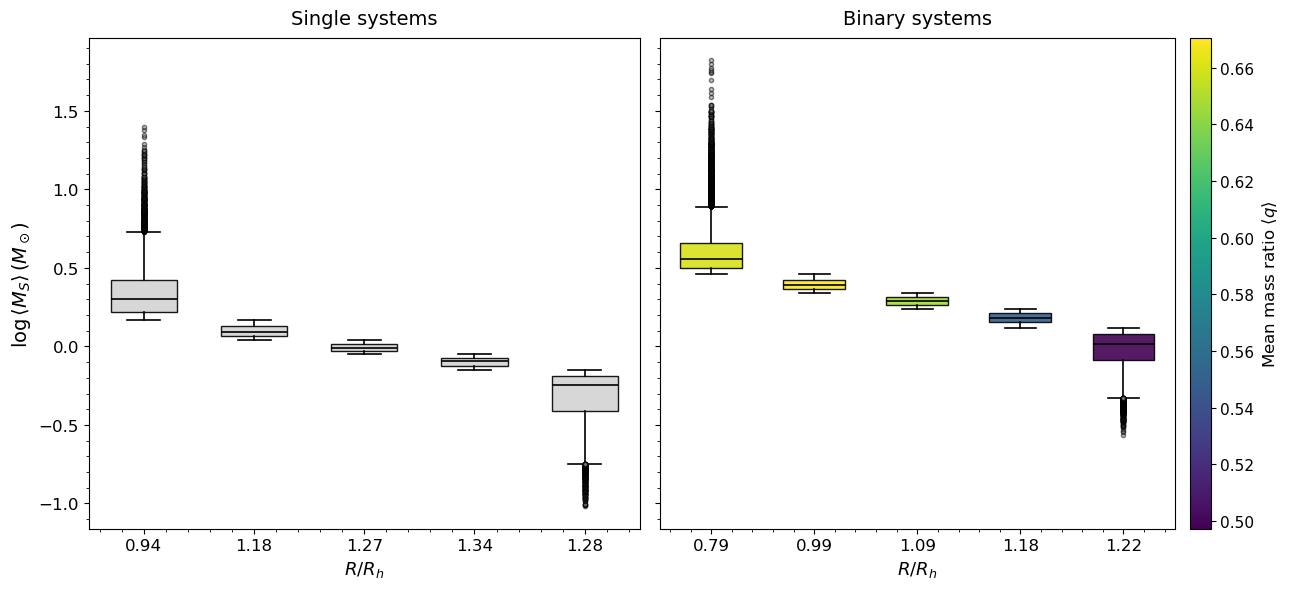

In [104]:
data['mass_system'] = data['mass'] + data['comp_mass']

binarias = data[data.q>0]
binarias =  binarias.sort_values(by='mass_system').reset_index(drop=True)

singles = data[data.q==0]
singles = singles.sort_values(by='mass_system').reset_index(drop=True)

n_div = 5

subconjuntos_singles = np.array_split(singles, n_div)
subconjuntos_binarias = np.array_split(binarias, n_div)

# Dados para o boxplot
box_mass_bin = []       # valores de r/rh por bin
box_q = []         # razão de massa média por bin
box_labels_bin = []    # rótulos de massa média por bin

box_mass_sig = []
box_labels_sig = []

for i in range(n_div):
    rrh_mean = subconjuntos_binarias[i]['r/rh'].median()
    q_mean = subconjuntos_binarias[i]['q'].mean()
    m_vals = subconjuntos_binarias[i]['mass_system'].values

    box_mass_bin.append(np.log10(m_vals))
    box_q.append(q_mean)
    box_labels_bin.append(f'{rrh_mean:.2f}')

    rrh_mean = subconjuntos_singles[i]['r/rh'].median()

    m_vals = subconjuntos_singles[i]['mass_system'].values

    box_mass_sig.append(np.log10(m_vals))
    box_labels_sig.append(f'{rrh_mean:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

# ==========================
# Colormap
# ==========================
norm = mcolors.Normalize(vmin=np.min(box_q), vmax=np.max(box_q))
cmap = cm.viridis


def styled_boxplot(ax, data, box_labels, title, color_by_q=True):

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        flierprops=dict(
            marker='o',
            markersize=3,
            markerfacecolor='gray',
            markeredgecolor='black',
            alpha=0.5
        )
    )

    # Colorir boxes
    for i, patch in enumerate(bp['boxes']):
        if color_by_q:
            patch.set_facecolor(cmap(norm(box_q[i])))
        else:
            patch.set_facecolor('lightgray')
        patch.set_edgecolor('black')
        patch.set_alpha(0.9)

    # Estilo linhas
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.2)

    # Eixos
    ax.set_xticks(np.arange(1, n_div + 1))
    ax.set_xticklabels(box_labels, fontsize=12)
    ax.set_xlabel(r'$R / R_h$', fontsize=13)
    ax.set_title(title, fontsize=14, pad=10)

    ax.tick_params(axis='y', labelsize=12)
    ax.minorticks_on()
    ax.invert_xaxis()

    return bp


# ==========================
# Painéis
# ==========================
styled_boxplot(
    ax[1],
    box_mass_bin,
    box_labels_bin,
    title='Binary systems'
)

styled_boxplot(
    ax[0],
    box_mass_sig,
    box_labels_sig,
    title='Single systems',
    color_by_q=False
)

# ==========================
# Eixo Y único
# ==========================
ax[0].set_ylabel(
    r'$\log\langle M_S \rangle\,(M_\odot)$',
    fontsize=14
)

# ==========================
# Colorbar
# ==========================
from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="4%", pad=0.15)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'Mean mass ratio $\langle q \rangle$', fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()


In [15]:
subconjuntos_binarias[0]

Index(['pmRApmDEcor', 'PlxpmRAcor', 'PlxpmDEcor', 'Nper', 'RA_ICRS',
       'e_RA_ICRS', 'DE_ICRS', 'e_DE_ICRS', 'Source', 'Plx', 'e_Plx', 'pmRA',
       'e_pmRA', 'pmDE', 'e_pmDE', 'RUWE', 'Gmag', 'e_Gmag', 'BPmag',
       'e_BPmag', 'RPmag', 'e_RPmag', 'BPRP', 'RVDR2', 'e_RVDR2', 'EBPRP',
       'RFG', 'RFBP', 'RFRP', 'Pmemb', 'mass', 'er_mass', 'comp_mass',
       'er_comp_mass', 'Cluster.1', 'q', 'r/rh', 'mass_system'],
      dtype='object')

# $T_{relax}$ and $\tau$ parameter


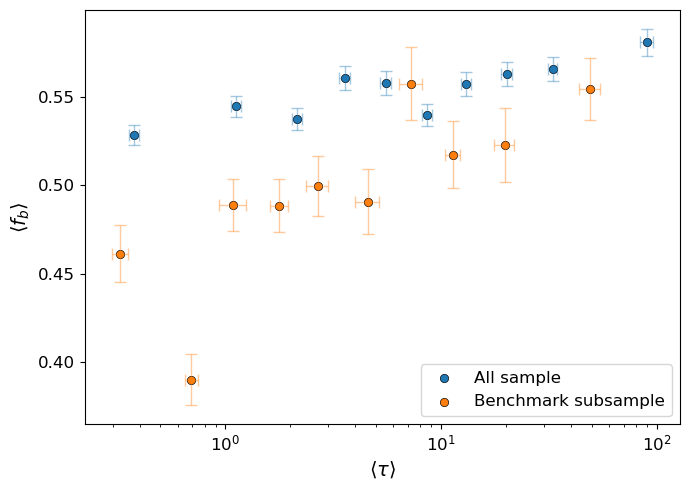

In [9]:
subconjuntos = np.array_split(df.sort_values(by='tau'), 10)
benchmark_subsample = df[(df['dist']<1.5) & (df['Av']<0.5)]
subconjuntos_benchmark = np.array_split(benchmark_subsample.sort_values(by='tau'), 10)

tau_mean = []
tau_benchmark_mean = []
bin_frac_mean = []
bin_frac_benchmark_mean = []

for i in range(len(subconjuntos)):
    tau_vals = subconjuntos[i]["tau"].values
    tau_errs = subconjuntos[i]["e_tau"].values
    tau_ufloats = unp.uarray(tau_vals, tau_errs)
    tau_mean.append((tau_ufloats).mean())

    tau_b_vals = subconjuntos_benchmark[i]["tau"].values
    tau_b_errs = subconjuntos_benchmark[i]["e_tau"].values
    tau_b_ufloats = unp.uarray(tau_b_vals, tau_b_errs)
    tau_benchmark_mean.append((tau_b_ufloats).mean())

    # bin_frac y er_bin_frac
    bf_vals = subconjuntos[i]["bin_frac_corr"].values
    bf_errs = subconjuntos[i]["e_bin_frac"].values
    bf_ufloats = unp.uarray(bf_vals, bf_errs)
    bin_frac_mean.append((bf_ufloats).mean())

    bf_b_vals = subconjuntos_benchmark[i]["bin_frac_corr"].values
    bf_b_errs = subconjuntos_benchmark[i]["e_bin_frac"].values
    bf_b_ufloats = unp.uarray(bf_b_vals, bf_b_errs)
    bin_frac_benchmark_mean.append((bf_b_ufloats).mean())

tau_mean = np.array(tau_mean)
tau_benchmark_mean = np.array(tau_benchmark_mean)
bin_frac_mean = np.array(bin_frac_mean)
bin_frac_benchmark_mean = np.array(bin_frac_benchmark_mean)

x = unp.nominal_values(tau_mean)
y = unp.nominal_values(bin_frac_mean)
xerr = unp.std_devs(tau_mean)
yerr = unp.std_devs(bin_frac_mean)

x_bench = unp.nominal_values(tau_benchmark_mean)
y_bench = unp.nominal_values(bin_frac_benchmark_mean)
xerr_bench = unp.std_devs(tau_benchmark_mean)
yerr_bench = unp.std_devs(bin_frac_benchmark_mean)

fig, ax = plt.subplots(figsize=(7, 5))

# Scatterplot para todos os dados
sns.scatterplot(x=x, y=y, ax=ax, label='All sample', color='tab:blue', edgecolor='k',)
ax.errorbar(x, y,xerr=xerr, yerr=yerr,fmt='none',ecolor='tab:blue',alpha=0.4,capsize=4,elinewidth=1,)

# Scatterplot para benchmark
sns.scatterplot(x=x_bench, y=y_bench,ax=ax,label='Benchmark subsample',color='tab:orange',edgecolor='k',)
ax.errorbar(x_bench, y_bench,xerr=xerr_bench, yerr=yerr_bench,fmt='none',ecolor='tab:orange',alpha=0.4,capsize=4,elinewidth=1,)

# Escala logarítmica no eixo x
ax.set_xscale('log')

ax.set_xlabel(r"$\langle \tau \rangle$", fontdict=font)
ax.set_ylabel(r"$\langle f_b \rangle$", fontdict=font)
ax.tick_params(axis='both', labelsize=labelsize)


ax.legend(loc='lower right', fontsize=12,)

plt.tight_layout()
plt.savefig('Figures/fb_tau.png', dpi=300)
plt.show()


In [154]:
np.median(binary_system_r_rh)

1.2840449616559386

In [145]:
subconjuntos_singles[0]

,pmRApmDEcor,PlxpmRAcor,PlxpmDEcor,Nper,RA_ICRS,e_RA_ICRS,DE_ICRS,e_DE_ICRS,Source,Plx,...,RFRP,Pmemb,mass,er_mass,comp_mass,er_comp_mass,Cluster.1,q,r/rh,mass_system
0,0.1874,-0.0412,-0.1637,25,140.132191,0.1716,-57.874530,0.1606,5306655642962516736,8.0791,...,164.472,1.00,0.095715,0.001510,0.0,0.000000,Platais_8,0.0,1.114595,0.095715
1,0.1055,0.1451,0.1985,24,140.706272,0.1796,-59.442945,0.1979,5300323658603184256,6.5948,...,94.379,1.00,0.097051,0.002156,0.0,0.000000,Platais_8,0.0,1.301682,0.097051
2,-0.0365,0.1285,-0.1843,25,137.228132,0.1676,-59.603264,0.1507,5300139451730729728,7.3757,...,139.482,1.00,0.097412,0.002428,0.0,0.000000,Platais_8,0.0,0.638829,0.097412
3,-0.0490,0.1041,0.1454,28,162.278937,0.1640,-64.050956,0.1466,5241165603717883776,6.5330,...,99.219,1.00,0.098069,0.002339,0.0,0.000000,IC_2602,0.0,1.105308,0.098069
4,-0.0522,0.0623,-0.0160,25,137.651134,0.1655,-59.162798,0.1688,5300527648055854464,7.3900,...,138.854,1.00,0.099061,0.003283,0.0,0.000000,Platais_8,0.0,0.424195,0.099061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16288,-0.0085,0.0026,0.1285,20,98.997903,0.1043,-14.224279,0.1179,2950826356953126272,0.6610,...,88.567,0.98,0.704097,0.001365,0.0,0.059864,Ruprecht_1,0.0,0.782985,0.704097
16289,0.1565,-0.0656,-0.1771,18,253.873618,0.2192,-39.616019,0.1185,5969797798905161600,0.9842,...,106.747,0.83,0.704103,0.002295,0.0,0.046380,NGC_6242,0.0,1.375959,0.704103
16290,-0.3382,-0.1895,0.0168,26,308.739077,0.0420,28.112433,0.0562,1857456807300384128,0.9885,...,157.210,1.00,0.704112,0.000953,0.0,0.047704,NGC_6940,0.0,0.841919,0.704112
16291,-0.1601,0.0922,0.1311,26,130.974238,0.1104,-45.730410,0.1292,5522027048607698688,0.5822,...,82.432,0.74,0.704133,0.003587,0.0,0.035354,LP_2219,0.0,0.298234,0.704133


In [146]:
subconjuntos_binarias[0]

,pmRApmDEcor,PlxpmRAcor,PlxpmDEcor,Nper,RA_ICRS,e_RA_ICRS,DE_ICRS,e_DE_ICRS,Source,Plx,...,RFRP,Pmemb,mass,er_mass,comp_mass,er_comp_mass,Cluster.1,q,r/rh,mass_system
1796,0.0154,-0.0386,-0.2759,16,1.106996,0.2449,-30.154853,0.1732,2320800112563994112,4.3216,...,137.621,1.00,0.164951,0.011146,0.109312,0.044497,Blanco_1,0.662697,0.442786,0.274263
2008,-0.4198,0.2127,-0.4434,17,115.864074,0.2067,0.905304,0.1625,3086816605074848640,3.2728,...,123.438,0.94,0.176266,0.013838,0.110397,0.048201,ASCC_41,0.626305,1.96279,0.286663
2073,0.2164,-0.0398,-0.2632,17,0.791793,0.1330,-29.965344,0.1172,2320820109931857792,4.5404,...,178.972,1.00,0.188656,0.014175,0.101436,0.057049,Blanco_1,0.537677,0.758774,0.290092
2182,0.0168,-0.0105,0.0718,25,346.848043,0.1844,65.689333,0.1881,2208966311003268992,2.5390,...,84.490,1.00,0.186189,0.018334,0.109600,0.059461,ASCC_127,0.588648,1.357884,0.295789
2366,0.1135,0.0489,-0.2007,28,116.034126,0.0689,-36.979597,0.0852,5586965270494703232,5.3847,...,200.895,1.00,0.173774,0.009546,0.133822,0.020709,NGC_2451A,0.770094,1.290093,0.307596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67939,-0.1167,-0.2770,0.1291,25,345.890751,0.0696,63.251256,0.0612,2207639922020711040,1.0833,...,222.722,0.97,0.691917,0.014144,0.622737,0.038556,UBC_178,0.900017,0.750758,1.314654
67940,0.0753,0.0784,-0.0938,28,107.998442,0.0152,-25.850968,0.0223,5611125290468720000,0.8292,...,1061.874,0.99,1.006767,0.002232,0.307911,0.230691,NGC_2354,0.305841,3.348689,1.314678
67944,-0.2501,0.2087,-0.2470,20,113.372783,0.1157,-15.489003,0.1332,3028363401551345920,0.2065,...,55.885,0.91,1.126194,0.013994,0.188578,0.322723,NGC_2414,0.167447,2.082649,1.314772
67948,-0.2628,-0.0751,-0.1853,22,303.424363,0.0833,26.509994,0.1331,1835716851074357376,0.6880,...,154.346,0.87,0.719313,0.021384,0.595491,0.070263,Gulliver_18,0.827861,2.827135,1.314805
